## Finance Case Study :

In [1]:
import pandas as pd
import numpy as np
from numpy import log
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Set pandas display options to show more columns
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)        # Prevent line wrapping

In [2]:
info = pd.read_excel(r"C:\Users\Kush\OneDrive\Documents\SDBI\Machine Learning\Finance\Data\DigiHack Dataset.xlsx",sheet_name='Explanation')
info

,Sr.no,Name,Description
0,1,ID,Customer ID
1,2,Age,Age of the Customer
2,3,Customer_type,Salaried / Self Employed
3,4,Gross_income,Gross income declared by Customer
4,5,Net_income,Net income declared by Customer
5,6,SEX,Gender
6,7,Type_of_industry,Type of industry
7,8,Marital_Status,Marital Status declared by Customer
8,9,Months_in_city,Months in city
9,10,Months_in_current_job,Months in current job


In [3]:
info[info['Name'] == 'ENQ_1'].Description.values

array(['Days since last enquiry was made with any other bank'],
      dtype=object)

In [4]:
info[info['Name'] == 'ACCOUNT_15'].Description.values

array(['Total number of live loans'], dtype=object)

In [5]:
df = pd.read_excel(r"C:\Users\Kush\OneDrive\Documents\SDBI\Machine Learning\Finance\Data\DigiHack Dataset.xlsx")
df.head()

,ID,Age,Customer_type,Gross_income,Net_income,SEX,Type_of_industry,Marital_Status,Months_in_city,Months_in_current_job,Org_Type,Bank_balance,Debt_ratio,Target,ENQ_1,ENQ_2,ENQ_3,ENQ_4,ENQ_5,ENQ_6,ENQ_7,ENQ_8,ACCOUNT_9,ACCOUNT_10,ACCOUNT_11,ACCOUNT_12,ACCOUNT_13,ACCOUNT_14,ACCOUNT_15,ACCOUNT_16,ACCOUNT_17,ACCOUNT_18,ACCOUNT_19,ACCOUNT_20,ACCOUNT_21
0,1,42.0,SELF EMPLOYED,91666.67,91666.6667,MALE,CONSTRUCTION,MARRIED,0.0,96,PROPRIETORSHIP,267532.0,0.63,0,17,220,1,0,8,6,25,7,1,1,419,13,0,5,3,0,3,1837374,0,1837374,1657
1,1,42.0,SELF EMPLOYED,91666.67,91666.6667,MALE,CONSTRUCTION,MARRIED,0.0,96,PROPRIETORSHIP,267532.0,0.63,0,17,220,1,0,8,6,25,7,1,1,419,13,0,5,3,0,3,1837374,0,1837374,1657
2,2,38.0,SALARIED,150000.00,30000.0000,FEMALE,OTHERS,MARRIED,0.0,120,INDIVIDUAL,13059.0,0.39,1,5,0,1,0,2,0,6,0,0,0,121,4,0,3,2,0,2,10380,0,10380,124
3,2,38.0,SALARIED,150000.00,30000.0000,FEMALE,OTHERS,MARRIED,0.0,120,INDIVIDUAL,13059.0,0.39,1,5,0,1,0,2,0,6,0,0,0,121,4,0,3,2,0,2,10380,0,10380,124
4,3,36.0,SELF EMPLOYED,188183.33,188183.3333,MALE,OTHERS,MARRIED,0.0,0,PROPRIETORSHIP,NaN,0.44,0,5,5,7,6,13,8,50,11,6,6,87,30,2,21,8,1,7,3445241,1536325,1908916,2534


In [6]:
df.columns = df.columns.str.lower()

In [7]:
df.rename( columns = {'enq_1':'days_last_enq',
'enq_2':'days_hl_last_enq',
'enq_3':'no_enq_l3',
'enq_4':'no_hl_enq_l3',
'enq_5':'no_enq_l12',
'enq_6':'no_hl_enq_l12',
'enq_7':'no_enq',
'enq_8':'no_hl_enq',
'account_9':'no_def_l3',
'account_10':'no_def_l12',
'account_11':'days_last_acc_open',
'account_12':'no_acc_lc',
'account_13':'no_hl_acc_lc',
'account_14':'no_unsec_acc_lc',
'account_15':'no_live_acc',
'account_16':'no_live_hl_acc',
'account_17':'no_live_unsec_acc',
'account_18':'os_amt',
'account_19':'sec_os_amt',
'account_20':'unsec_os_amt',
'account_21':'avg_debt_days',
}, inplace = True)

### Data pre-processing :

In [8]:
df.shape

(3980, 35)

In [9]:
df.head()

,id,age,customer_type,gross_income,net_income,sex,type_of_industry,marital_status,months_in_city,months_in_current_job,org_type,bank_balance,debt_ratio,target,days_last_enq,days_hl_last_enq,no_enq_l3,no_hl_enq_l3,no_enq_l12,no_hl_enq_l12,no_enq,no_hl_enq,no_def_l3,no_def_l12,days_last_acc_open,no_acc_lc,no_hl_acc_lc,no_unsec_acc_lc,no_live_acc,no_live_hl_acc,no_live_unsec_acc,os_amt,sec_os_amt,unsec_os_amt,avg_debt_days
0,1,42.0,SELF EMPLOYED,91666.67,91666.6667,MALE,CONSTRUCTION,MARRIED,0.0,96,PROPRIETORSHIP,267532.0,0.63,0,17,220,1,0,8,6,25,7,1,1,419,13,0,5,3,0,3,1837374,0,1837374,1657
1,1,42.0,SELF EMPLOYED,91666.67,91666.6667,MALE,CONSTRUCTION,MARRIED,0.0,96,PROPRIETORSHIP,267532.0,0.63,0,17,220,1,0,8,6,25,7,1,1,419,13,0,5,3,0,3,1837374,0,1837374,1657
2,2,38.0,SALARIED,150000.00,30000.0000,FEMALE,OTHERS,MARRIED,0.0,120,INDIVIDUAL,13059.0,0.39,1,5,0,1,0,2,0,6,0,0,0,121,4,0,3,2,0,2,10380,0,10380,124
3,2,38.0,SALARIED,150000.00,30000.0000,FEMALE,OTHERS,MARRIED,0.0,120,INDIVIDUAL,13059.0,0.39,1,5,0,1,0,2,0,6,0,0,0,121,4,0,3,2,0,2,10380,0,10380,124
4,3,36.0,SELF EMPLOYED,188183.33,188183.3333,MALE,OTHERS,MARRIED,0.0,0,PROPRIETORSHIP,NaN,0.44,0,5,5,7,6,13,8,50,11,6,6,87,30,2,21,8,1,7,3445241,1536325,1908916,2534


In [10]:
df.columns

Index(['id', 'age', 'customer_type', 'gross_income', 'net_income', 'sex',
       'type_of_industry', 'marital_status', 'months_in_city',
       'months_in_current_job', 'org_type', 'bank_balance', 'debt_ratio',
       'target', 'days_last_enq', 'days_hl_last_enq', 'no_enq_l3',
       'no_hl_enq_l3', 'no_enq_l12', 'no_hl_enq_l12', 'no_enq', 'no_hl_enq',
       'no_def_l3', 'no_def_l12', 'days_last_acc_open', 'no_acc_lc',
       'no_hl_acc_lc', 'no_unsec_acc_lc', 'no_live_acc', 'no_live_hl_acc',
       'no_live_unsec_acc', 'os_amt', 'sec_os_amt', 'unsec_os_amt',
       'avg_debt_days'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3980 entries, 0 to 3979
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3980 non-null   int64  
 1   age                    3979 non-null   float64
 2   customer_type          3980 non-null   object 
 3   gross_income           3980 non-null   float64
 4   net_income             3980 non-null   float64
 5   sex                    3976 non-null   object 
 6   type_of_industry       3975 non-null   object 
 7   marital_status         3976 non-null   object 
 8   months_in_city         3976 non-null   float64
 9   months_in_current_job  3980 non-null   int64  
 10  org_type               3980 non-null   object 
 11  bank_balance           3344 non-null   float64
 12  debt_ratio             3980 non-null   float64
 13  target                 3980 non-null   int64  
 14  days_last_enq          3980 non-null   int64  
 15  days

### EDA and Visualisation :

In [12]:
df.drop_duplicates(inplace = True)
df.drop('id',axis = 1,inplace =True)

In [13]:
for i in df.columns:
    if df[i].dtype == 'object':
        print(i)
        
        print("Num Unique: ",df[i].nunique())
        print("Unique: ",df[i].unique())
        
        print('-------')

customer_type
Num Unique:  3
Unique:  ['SELF EMPLOYED' 'SALARIED' 'NON EARNING']
-------
sex
Num Unique:  2
Unique:  ['MALE' 'FEMALE' nan]
-------
type_of_industry
Num Unique:  80
Unique:  ['CONSTRUCTION' 'OTHERS' 'AGRICULTURE' 'FMCG' 'EDUCATION'
 'GEMS AND JEWELLRY' 'TEXTILES' 'CONSUMER ELECTRONICS'
 'MILK AND DAIRY PRODUCTS' 'FOOD PRODUCTS' 'TRANSPORT LOGISTICS'
 'TEXTILE READY MADE GARMENTS' 'AUTOMOTIVE'
 'PLASTIC PIPE AND PIPE FITTINGS' 'TRAVEL AGENTS AND TOUR OPERATORS'
 'OIL AND GAS ALLIED' 'GOVERNMENT' 'BANKING AND FINANCE' 'MEDIA'
 'ELECTRONICS' 'INSTITUTIONS AND TRUST' 'HOTELS AND RESORTS'
 'ELECTRICAL MACHINERY' 'ELECTRICAL EQUIPMENT AND COMPONENTS'
 'PRINT MANUFACTURE RECORD MEDIA' 'ENGINEERING'
 'HEALTHCARE AND HEALTHCARE PROVIDERS' 'TRANSPORT OPERATOR'
 'AUTO COMPONENTS' 'IT AND COMMUNICATION' 'PAINTS'
 'TEXTILE WEAVING KNITTING AND PROCESSING' 'IT HARDWARE'
 'MEDICAL EQUIPMENT' 'WOOD AND WOOD PRODUCTS'
 'HOSPITALS AND NURSING HOMES' 'LEATHER' 'INDUSTRIAL EQUIPMENT'
 'MACH

In [14]:
for i in df.columns:
    if df[i].dtype == 'object':
        
        print(df[i].value_counts())
        
        print('------'*10)

customer_type
SELF EMPLOYED    2202
SALARIED         1669
NON EARNING        23
Name: count, dtype: int64
------------------------------------------------------------
sex
MALE      3278
FEMALE     612
Name: count, dtype: int64
------------------------------------------------------------
type_of_industry
OTHERS                                     3190
TEXTILES                                     67
CONSTRUCTION                                 52
FOOD PRODUCTS                                41
IT AND COMMUNICATION                         38
                                           ... 
PHARMACEUTICALS FORMULATIONS                  1
PLYWOOD AND LAMINATES                         1
TEXTILE WEAVING KNITTING AND PROCESSING       1
IT HARDWARE                                   1
CERAMIC TILES AND SANITARY WARE               1
Name: count, Length: 80, dtype: int64
------------------------------------------------------------
marital_status
MARRIED      3467
SINGLE        404
WIDOWED        11

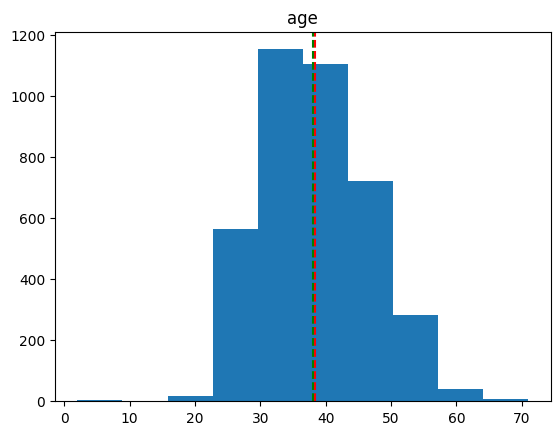

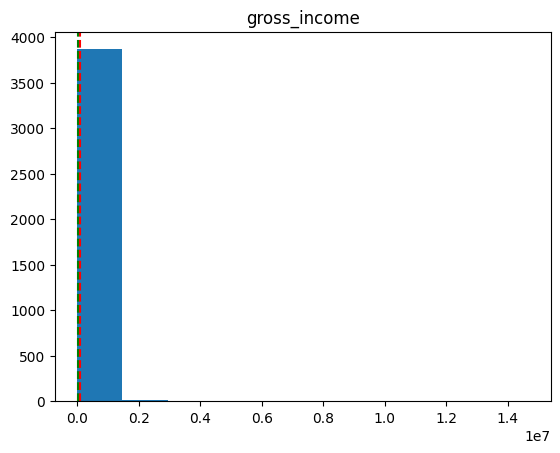

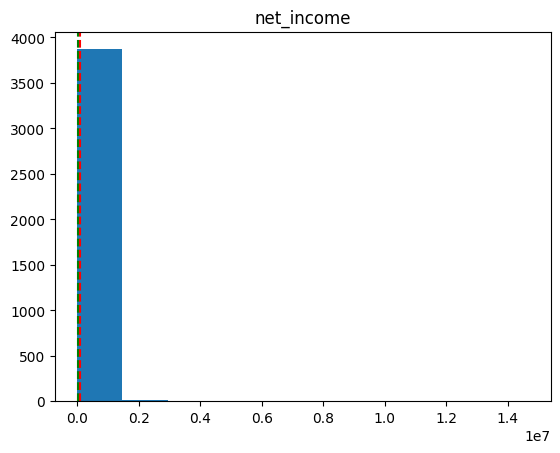

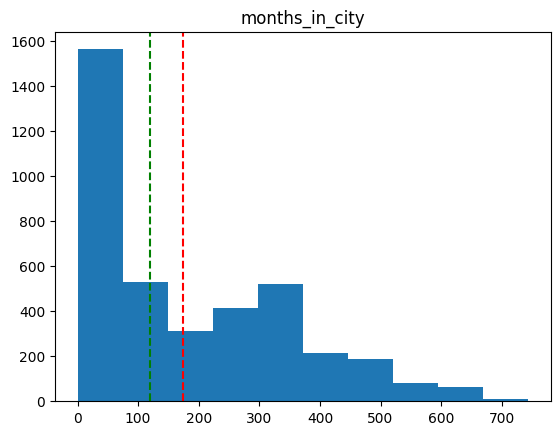

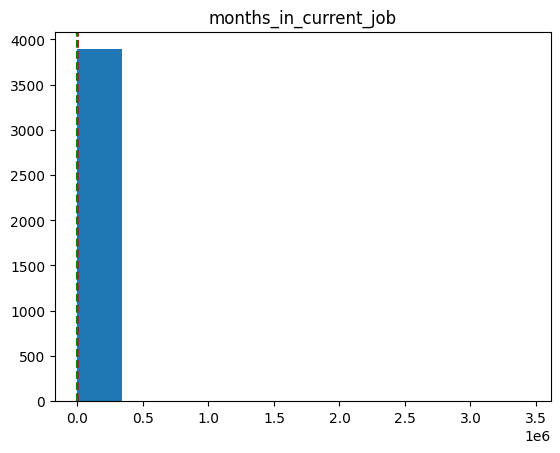

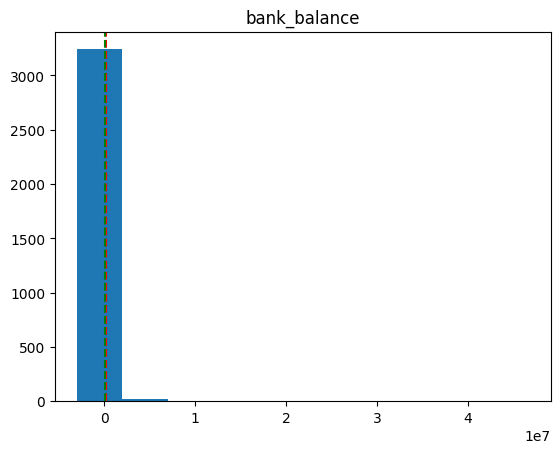

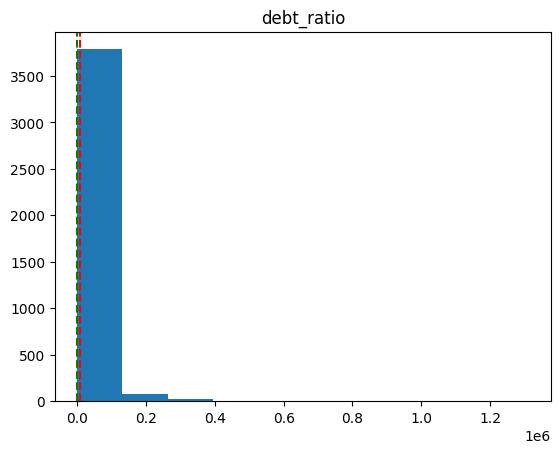

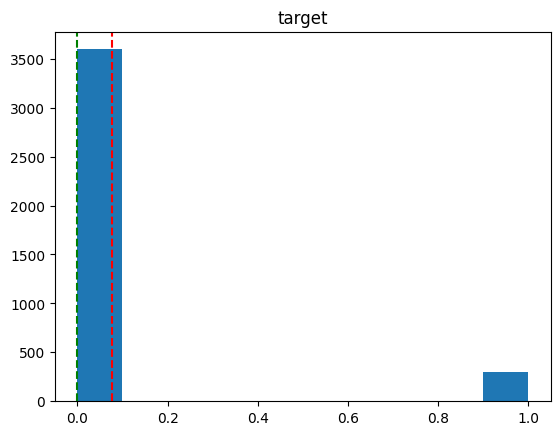

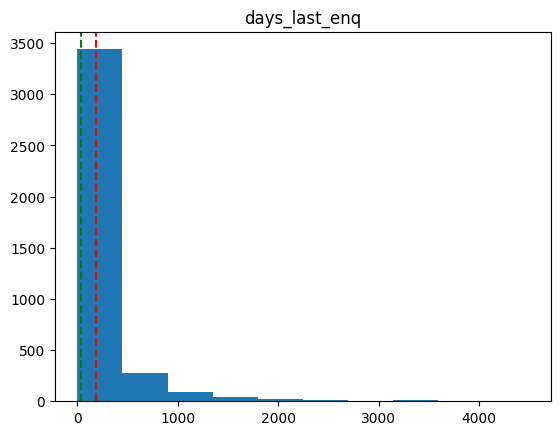

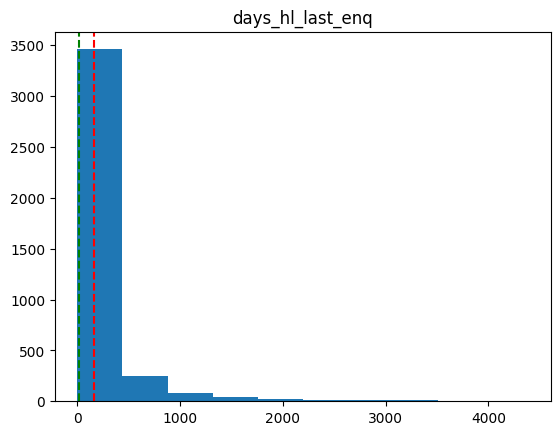

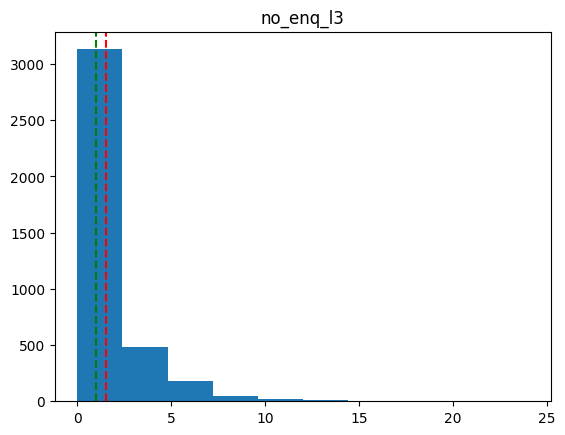

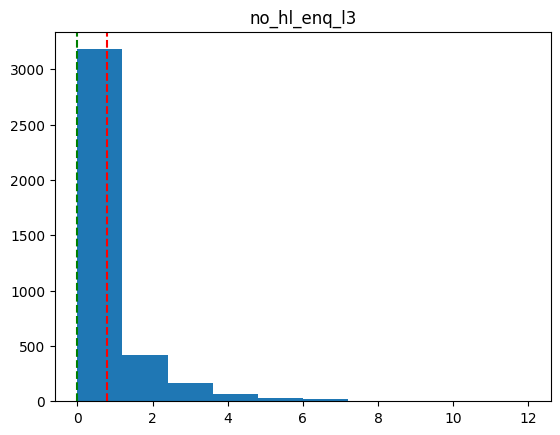

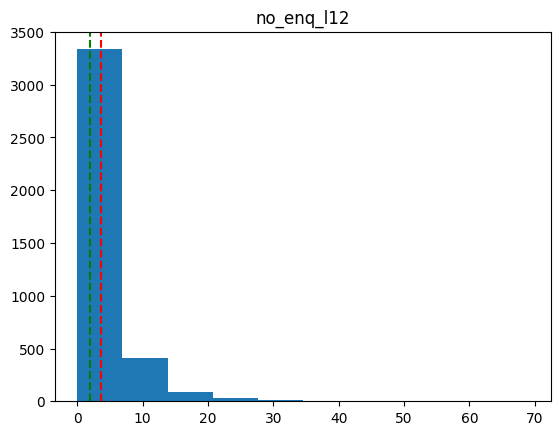

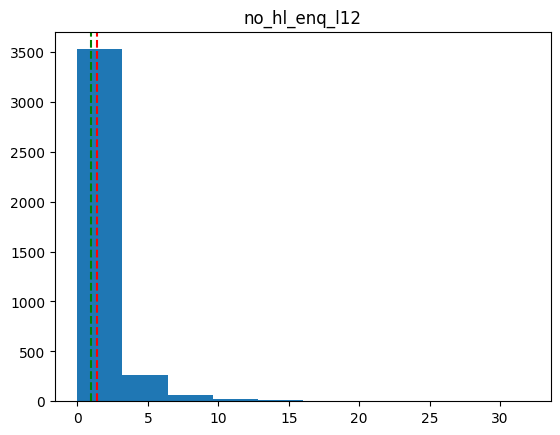

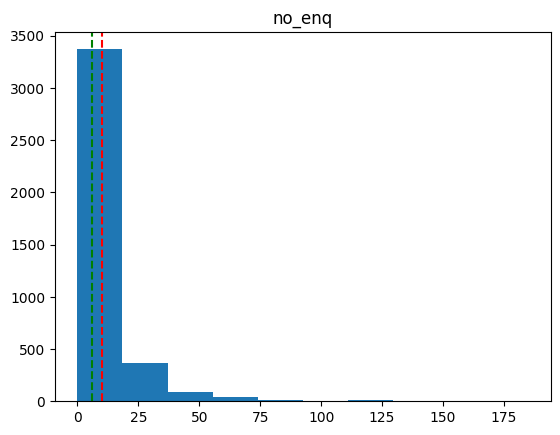

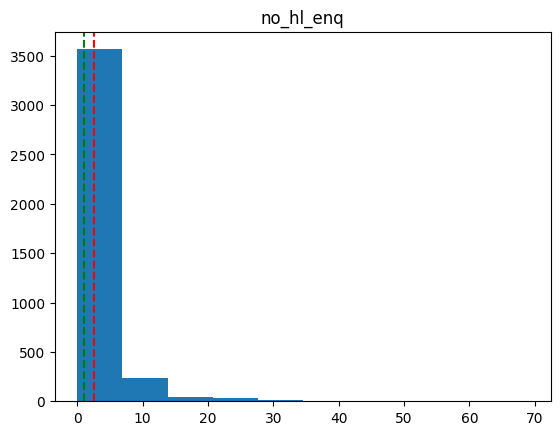

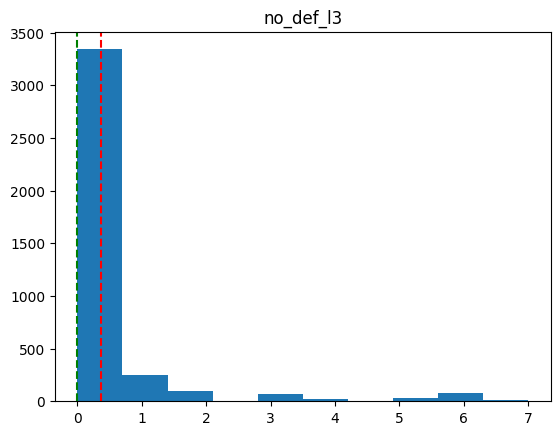

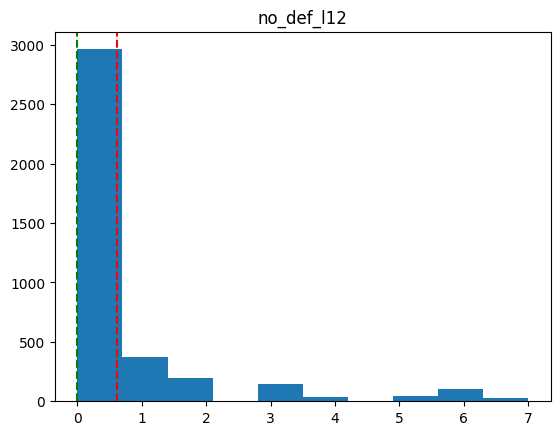

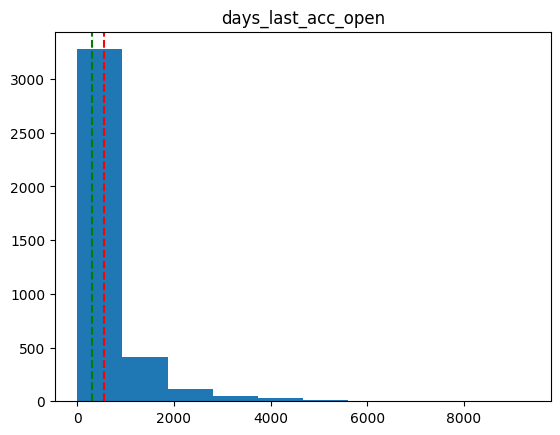

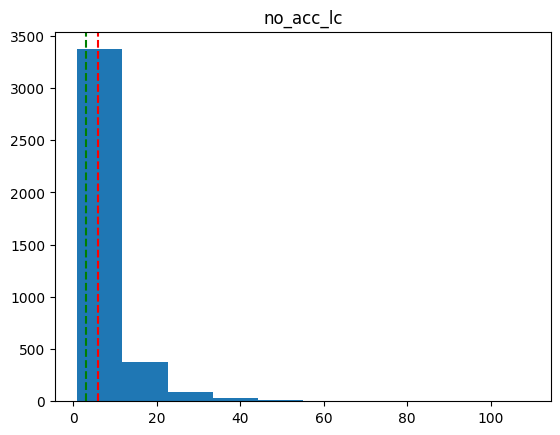

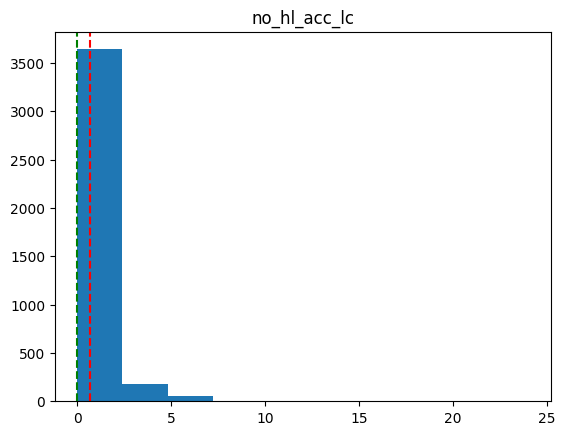

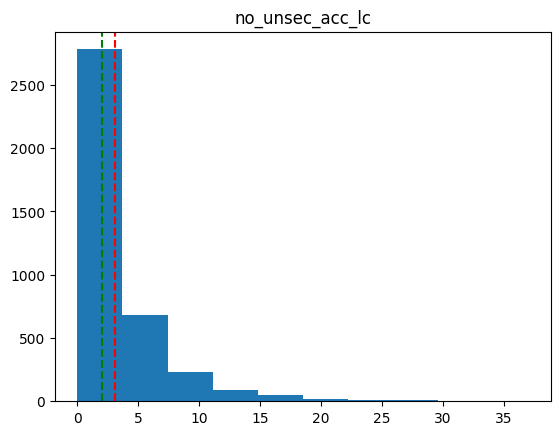

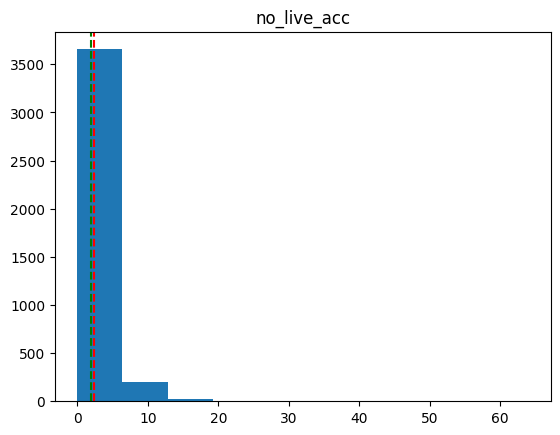

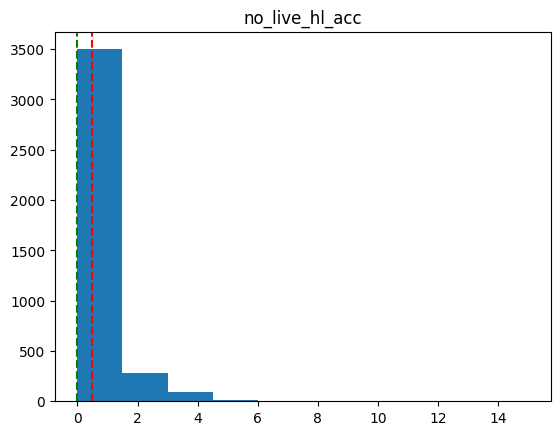

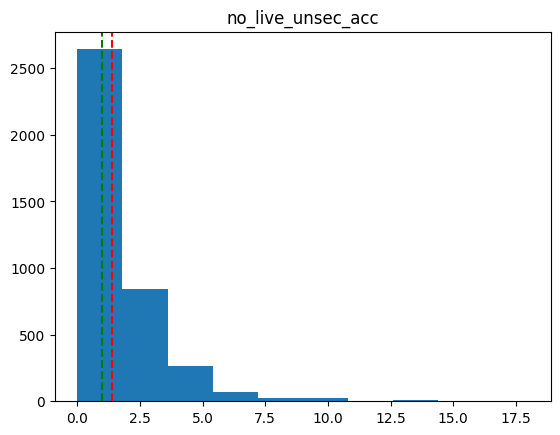

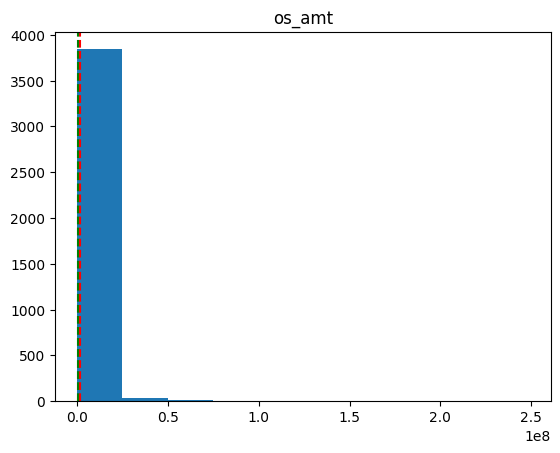

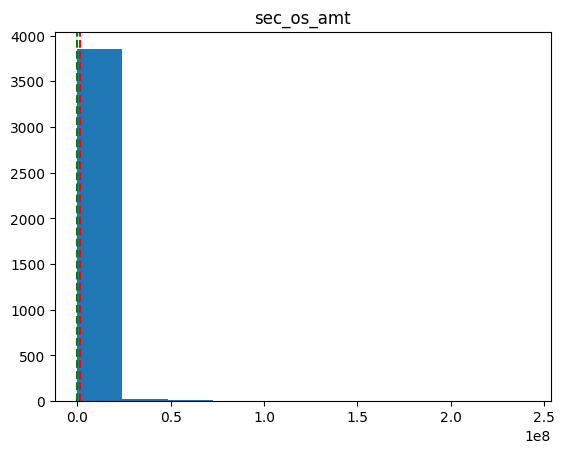

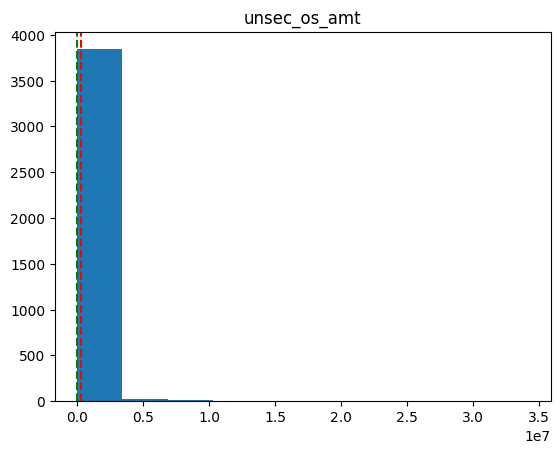

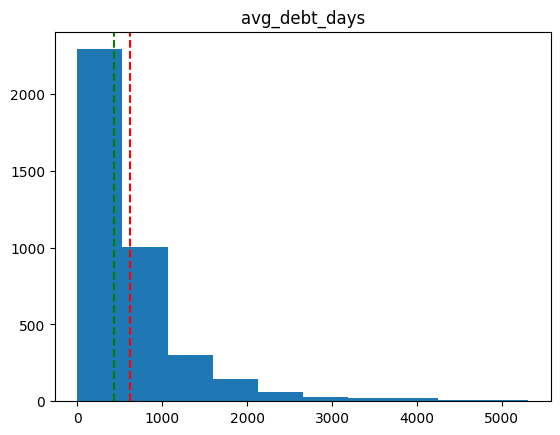

In [15]:
for i in df.describe().columns:
    plt.title(i)
    plt.hist(df[i])
    plt.axvline(df[i].mean(),c = 'r', linestyle = '--',label = 'meam')
    plt.axvline(df[i].median(),c = 'g', linestyle = '--',label = 'median')
    
    plt.show()

In [16]:
missing_number = df.isna().sum()
missing_percentage = missing_number*100/len(df)

missing_info = pd.concat([missing_number,missing_percentage],axis = 1, keys = ['missing_number','missing_percentage'])
missing_info.sort_values(by = 'missing_number',ascending=False).head(10)

,missing_number,missing_percentage
bank_balance,626,16.076014
type_of_industry,5,0.128403
sex,4,0.102722
marital_status,4,0.102722
months_in_city,4,0.102722
age,1,0.025681
no_live_acc,0,0.000000
no_def_l12,0,0.000000
days_last_acc_open,0,0.000000
no_acc_lc,0,0.000000


In [17]:
df.corr(numeric_only=True)['bank_balance'].sort_values(ascending=False)

bank_balance             1.000000
sec_os_amt               0.403694
os_amt                   0.385850
net_income               0.319774
gross_income             0.308794
no_live_acc              0.304991
no_enq                   0.212036
no_hl_enq                0.209873
no_acc_lc                0.208559
no_live_hl_acc           0.144582
no_hl_acc_lc             0.131753
no_enq_l12               0.091314
no_hl_enq_l12            0.081544
avg_debt_days            0.044596
no_enq_l3                0.043381
no_hl_enq_l3             0.042715
unsec_os_amt             0.041621
age                      0.032994
no_unsec_acc_lc          0.023791
months_in_city           0.012665
no_live_unsec_acc        0.003733
days_hl_last_enq        -0.000160
target                  -0.000880
months_in_current_job   -0.002130
no_def_l3               -0.006495
days_last_enq           -0.008174
no_def_l12              -0.009179
days_last_acc_open      -0.010020
debt_ratio              -0.010399
Name: bank_bal

In [18]:
df['age_bkt'] = pd.qcut(df.age, q =4)

for i in df['age_bkt'].unique().tolist():
    print(i)
    display(df[df['age_bkt'] == i]['bank_balance'].mean()) 
    print('---')

(38.0, 44.0]


192015.3361227336

---
(32.0, 38.0]


156622.09879518073

---
(1.999, 32.0]


...

---
(44.0, 71.0]


176256.89782886335

---
nan


nan

---


In [19]:
df['tmp_bb'] = df.groupby(['customer_type','age_bkt','sex'])['bank_balance'].transform('mean')

df[['tmp_bb','bank_balance'] ].isna().sum()

tmp_bb           10
bank_balance    626
dtype: int64

In [20]:
df['new_bank_balance'] = np.where(df['bank_balance'].isna(),df['tmp_bb'] ,df['bank_balance'] )

In [21]:
df.shape

(3894, 37)

In [22]:
df = df[(df['new_bank_balance']>0)]

In [23]:
df = df.drop(['tmp_bb','bank_balance','age_bkt'],axis = 1)

df = df[df['customer_type'] !='NON EARNING']

In [24]:
missing_number = df.isna().sum()
missing_percentage = missing_number*100/len(df)

missing_info = pd.concat([missing_number,missing_percentage],axis = 1, keys = ['missing_number','missing_percentage'])
missing_info.sort_values(by = 'missing_number',ascending=False).head(10)

,missing_number,missing_percentage
sex,3,0.07768
type_of_industry,3,0.07768
marital_status,3,0.07768
months_in_city,3,0.07768
age,0,0.00000
no_live_acc,0,0.00000
no_def_l12,0,0.00000
days_last_acc_open,0,0.00000
no_acc_lc,0,0.00000
no_hl_acc_lc,0,0.00000


In [25]:
print(df.shape)
df = df.dropna()
print(df.shape)

(3862, 34)
(3856, 34)


In [26]:
df

,age,customer_type,gross_income,net_income,sex,type_of_industry,marital_status,months_in_city,months_in_current_job,org_type,debt_ratio,target,days_last_enq,days_hl_last_enq,no_enq_l3,no_hl_enq_l3,no_enq_l12,no_hl_enq_l12,no_enq,no_hl_enq,no_def_l3,no_def_l12,days_last_acc_open,no_acc_lc,no_hl_acc_lc,no_unsec_acc_lc,no_live_acc,no_live_hl_acc,no_live_unsec_acc,os_amt,sec_os_amt,unsec_os_amt,avg_debt_days,new_bank_balance
0,42.0,SELF EMPLOYED,91666.67,91666.6667,MALE,CONSTRUCTION,MARRIED,0.0,96,PROPRIETORSHIP,0.63,0,17,220,1,0,8,6,25,7,1,1,419,13,0,5,3,0,3,1837374,0,1837374,1657,267532.000000
2,38.0,SALARIED,150000.00,30000.0000,FEMALE,OTHERS,MARRIED,0.0,120,INDIVIDUAL,0.39,1,5,0,1,0,2,0,6,0,0,0,121,4,0,3,2,0,2,10380,0,10380,124,13059.000000
4,36.0,SELF EMPLOYED,188183.33,188183.3333,MALE,OTHERS,MARRIED,0.0,0,PROPRIETORSHIP,0.44,0,5,5,7,6,13,8,50,11,6,6,87,30,2,21,8,1,7,3445241,1536325,1908916,2534,250925.046948
6,26.0,SALARIED,15488.00,27000.0000,MALE,OTHERS,MARRIED,324.0,0,PROPRIETORSHIP,0.55,1,63,63,1,1,3,1,4,1,0,0,416,1,0,0,1,0,0,63566,63566,0,416,7018.000000
8,40.0,SELF EMPLOYED,27305.42,27305.4167,MALE,OTHERS,MARRIED,0.0,206,PROPRIETORSHIP,0.55,0,2,342,2,0,4,1,7,1,6,6,2838,2,0,2,1,0,1,46848,0,46848,2838,163025.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3975,28.0,SALARIED,16090.00,16527.0000,FEMALE,OTHERS,MARRIED,0.0,36,INDIVIDUAL,0.45,0,19,0,2,0,5,0,6,0,0,0,325,3,0,2,2,0,1,112907,21754,91153,498,3860.000000
3976,27.0,SALARIED,14000.00,23266.0000,MALE,OTHERS,MARRIED,324.0,12,INDIVIDUAL,0.32,0,29,29,1,1,2,1,6,1,6,6,355,3,0,2,3,0,2,14492,0,14492,995,2024.000000
3977,43.0,SELF EMPLOYED,21506.25,21506.2500,MALE,OTHERS,MARRIED,324.0,82,INDIVIDUAL,0.38,0,96,96,0,0,1,1,2,1,0,0,640,1,0,0,1,0,0,11285,11285,0,640,40096.000000
3978,43.0,SELF EMPLOYED,0.08,0.0833,MALE,OTHERS,MARRIED,360.0,142,INDIVIDUAL,371721.50,0,103,103,0,0,4,1,11,2,5,5,183,10,0,9,5,0,4,601380,554259,47121,1565,36184.000000


In [27]:
df['target'].value_counts()

target
0    3566
1     290
Name: count, dtype: int64

In [28]:
print(df['marital_status'].unique())

df['marital_status'] = df['marital_status'].replace(
    {'WIDOWED': 'OTHER', 'DIVORCED': 'OTHER', 'SEPARATED': 'OTHER'}
)


df['marital_status'].unique()

['MARRIED' 'SINGLE' 'WIDOWED' 'DIVORCED' 'SEPARATED']


array(['MARRIED', 'SINGLE', 'OTHER'], dtype=object)

### Variable Creation :

<Axes: >

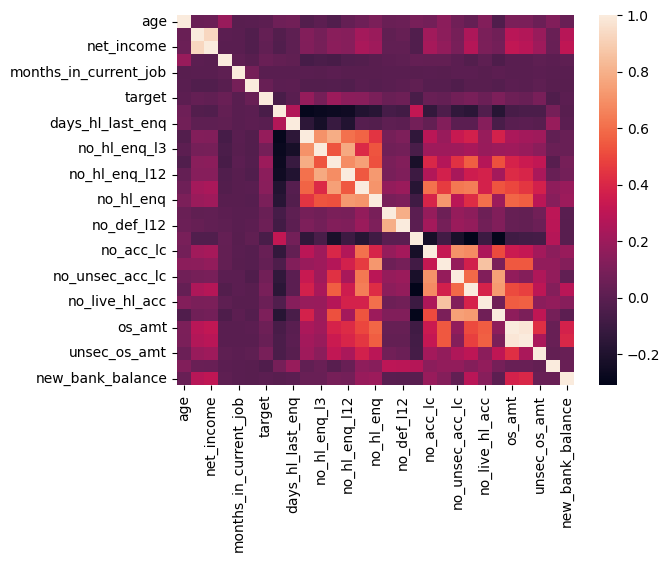

In [29]:
sns.heatmap(df.corr(numeric_only= True))

In [30]:
corr_matrix = df.corr(numeric_only=True)

for col in corr_matrix.columns:
   
    filtered_corr = corr_matrix[col][corr_matrix[col] > 0.7].drop(col)
    
    if not filtered_corr.empty:
        print(f"Column: {col}")
        print(filtered_corr.sort_values(ascending=False).head(3))  
        print('---')

Column: gross_income
net_income    0.931846
Name: gross_income, dtype: float64
---
Column: net_income
gross_income    0.931846
Name: net_income, dtype: float64
---
Column: no_enq_l3
no_enq_l12      0.788239
no_hl_enq_l3    0.706025
Name: no_enq_l3, dtype: float64
---
Column: no_hl_enq_l3
no_hl_enq_l12    0.778672
no_enq_l3        0.706025
Name: no_hl_enq_l3, dtype: float64
---
Column: no_enq_l12
no_enq_l3    0.788239
no_enq       0.746779
Name: no_enq_l12, dtype: float64
---
Column: no_hl_enq_l12
no_hl_enq_l3    0.778672
no_hl_enq       0.727550
Name: no_hl_enq_l12, dtype: float64
---
Column: no_enq
no_enq_l12    0.746779
no_hl_enq     0.712253
Name: no_enq, dtype: float64
---
Column: no_hl_enq
no_hl_enq_l12    0.727550
no_hl_acc_lc     0.720822
no_enq           0.712253
Name: no_hl_enq, dtype: float64
---
Column: no_def_l3
no_def_l12    0.793277
Name: no_def_l3, dtype: float64
---
Column: no_def_l12
no_def_l3    0.793277
Name: no_def_l12, dtype: float64
---
Column: no_acc_lc
no_unsec_

In [31]:
col = df.describe().columns.tolist()
col.remove('target')

In [32]:
print(df.shape)

for i in col:
    for j in col:
        if i == j:
            continue
        else:
            df[i+"_"+j] = df[i]/df[j]
            
print(df.shape)

(3856, 34)
(3856, 790)


In [33]:
df.shape

(3856, 790)

In [34]:
t_df = df.iloc[:,:34]

In [35]:
t_df = t_df.drop(columns='type_of_industry',axis = 1)

##### Creating a Decision Tree :

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

In [37]:
col = t_df.columns.to_list()

In [38]:
print(col)
col.remove('target')

['age', 'customer_type', 'gross_income', 'net_income', 'sex', 'marital_status', 'months_in_city', 'months_in_current_job', 'org_type', 'debt_ratio', 'target', 'days_last_enq', 'days_hl_last_enq', 'no_enq_l3', 'no_hl_enq_l3', 'no_enq_l12', 'no_hl_enq_l12', 'no_enq', 'no_hl_enq', 'no_def_l3', 'no_def_l12', 'days_last_acc_open', 'no_acc_lc', 'no_hl_acc_lc', 'no_unsec_acc_lc', 'no_live_acc', 'no_live_hl_acc', 'no_live_unsec_acc', 'os_amt', 'sec_os_amt', 'unsec_os_amt', 'avg_debt_days', 'new_bank_balance']


In [39]:
dt = DecisionTreeClassifier()

data =[]

for i in col:
    for j in col:
        if i==j:
            continue
        else:
            temp = t_df[[i,j,'target']]
                        
            X = t_df[[i,j]]
            X = pd.get_dummies(X, dtype=int)
            y = temp['target']
            
            dt.fit(X,y)
            
            y_pred = dt.predict(X)
            
            accuracy = accuracy_score(y,y_pred)

            f1score = f1_score(y,y_pred)
            
            row  = [i,j,accuracy,f1score]
            data.append(row)
            


In [40]:
model_performance = pd.DataFrame(data,columns=['a','b','accuracy','f1'])          
model_performance.drop_duplicates(['accuracy','f1'],inplace = True)

In [41]:
model_performance.sort_values(['accuracy','f1'],ascending=False).head(20)

,a,b,accuracy,f1
650,days_last_acc_open,new_bank_balance,1.000000,1.000000
81,gross_income,days_last_acc_open,0.999222,0.994801
112,net_income,days_last_acc_open,0.998963,0.993056
960,avg_debt_days,new_bank_balance,0.998703,0.991304
867,os_amt,new_bank_balance,0.998444,0.989547
646,days_last_acc_open,os_amt,0.997407,0.982456
92,gross_income,new_bank_balance,0.996888,0.978873
340,days_last_enq,new_bank_balance,0.996110,0.973638
119,net_income,os_amt,0.996110,0.973451
122,net_income,avg_debt_days,0.995851,0.971631


In [42]:
a = model_performance.sort_values('accuracy',ascending=False)['a'].head(30).to_list()

b = model_performance.sort_values('accuracy',ascending=False)['b'].head(30).to_list()

In [43]:
dt_vars = pd.Series(a+b).value_counts()
dt_vars

new_bank_balance         12
os_amt                    9
days_last_acc_open        6
net_income                6
gross_income              5
days_last_enq             5
avg_debt_days             4
debt_ratio                3
months_in_current_job     2
age                       2
no_enq                    1
months_in_city            1
no_hl_enq                 1
no_acc_lc                 1
no_live_unsec_acc         1
sec_os_amt                1
Name: count, dtype: int64

### Variable Selection :

#### 1. Information Value :

In [44]:
f = df.columns.to_list()
f.remove('target')
data = []


temp = []
temp_df = []

for i in f:
    try:
        if df[i].dtype=='object':
            temp_df = df[[i,'target']]

            temp = temp_df.pivot_table(index=i,columns = 'target',aggfunc='size')

        else:

            temp_df = df[[i,'target']]

            temp_df['f_bucket'] = pd.qcut(temp_df[i],10,duplicates='drop')

            temp = temp_df.pivot_table(index='f_bucket',columns = 'target',aggfunc='size')
            

        temp['%G'] = temp[0]/temp[0].sum()
        temp['%B'] = temp[1]/temp[1].sum()

        temp['LOG(%G / %B)'] = log(temp['%G']/ temp['%B'])
        temp['%G - %B'] =  temp['%G'] - temp['%B']

        temp['IV'] = temp['LOG(%G / %B)'] * temp['%G - %B']

        iv_value = np.round(temp['IV'].sum(),3)

        row = [i ,df[i].dtype, iv_value]

        data.append(row)
    except:
        data.append([i,df[i].dtype,'not_found'])



In [45]:
iv_data = pd.DataFrame(data, columns = ['name','d_type','IV'])

In [46]:
print(df.shape)
print(iv_data.shape)

(3856, 790)
(789, 3)


In [47]:
(iv_data['IV']=='not_found').sum()

618

In [48]:
iv_data[iv_data['IV']=='not_found']['d_type'].value_counts()

d_type
float64    618
Name: count, dtype: int64

In [49]:
iv_data[iv_data['IV']!='not_found'].sort_values(by='IV',ascending = False).head(15)

,name,d_type,IV
303,no_enq_l12_age,float64,0.327
15,no_enq_l12,int64,0.317
13,no_enq_l3,int64,0.267
1,customer_type,object,0.259
284,no_hl_enq_l3_no_enq_l3,float64,0.249
249,no_enq_l3_age,float64,0.234
357,no_enq_age,float64,0.232
87,net_income_age,float64,0.229
102,net_income_days_last_acc_open,float64,0.228
17,no_enq,int64,0.225


In [50]:
iv_columns = iv_data[iv_data['IV']!='not_found'].sort_values(by='IV',ascending = False).head(15)
selected_iv = iv_columns['name'].tolist()

#### 2. Feature Importance :

In [51]:
df

age  customer_type  gross_income   net_income     sex type_of_industry  \
0     42.0  SELF EMPLOYED      91666.67   91666.6667    MALE     CONSTRUCTION   
2     38.0       SALARIED     150000.00   30000.0000  FEMALE           OTHERS   
4     36.0  SELF EMPLOYED     188183.33  188183.3333    MALE           OTHERS   
6     26.0       SALARIED      15488.00   27000.0000    MALE           OTHERS   
8     40.0  SELF EMPLOYED      27305.42   27305.4167    MALE           OTHERS   
...    ...            ...           ...          ...     ...              ...   
3975  28.0       SALARIED      16090.00   16527.0000  FEMALE           OTHERS   
3976  27.0       SALARIED      14000.00   23266.0000    MALE           OTHERS   
3977  43.0  SELF EMPLOYED      21506.25   21506.2500    MALE           OTHERS   
3978  43.0  SELF EMPLOYED          0.08       0.0833    MALE           OTHERS   
3979  42.0  SELF EMPLOYED          0.08       0.0833    MALE         TEXTILES   

     marital_status  months_in_city  months_in_current_job        org_type  \
0           MARRIED             0.0                     96  PROPRIETORSHIP   
2           MARRIED             0.0                    120      INDIVIDUAL   
4           MARRIED             0.0                      0  PROPRIETORSHIP   
6           MARRIED           324.0                      0  PROPRIETORSHIP   
8           MARRIED             0.0                    206  PROPRIETORSHIP   
...             ...             ...                    ...             ...   
3975        MARRIED             0.0                     36      INDIVIDUAL   
3976        MARRIED           324.0                     12      INDIVIDUAL   
3977        MARRIED           324.0                     82      INDIVIDUAL   
3978        MARRIED           360.0                    142      INDIVIDUAL   
3979        MARRIED           324.0                     14      INDIVIDUAL   

      debt_ratio  target  days_last_enq  days_hl_last_enq  no_enq_l3  \
0           0.63       0             17               220          1   
2           0.39       1              5                 0          1   
4           0.44       0              5                 5          7   
6           0.55       1             63                63          1   
8           0.55       0              2               342          2   
...          ...     ...            ...               ...        ...   
3975        0.45       0             19                 0          2   
3976        0.32       0             29                29          1   
3977        0.38       0             96                96          0   
3978   371721.50       0            103               103          0   
3979    88057.38       0              3               114          1   

      no_hl_enq_l3  no_enq_l12  no_hl_enq_l12  no_enq  no_hl_enq  no_def_l3  \
0                0           8              6      25          7          1   
2                0           2              0       6          0          0   
4                6          13              8      50         11          6   
6                1           3              1       4          1          0   
8                0           4              1       7          1          6   
...            ...         ...            ...     ...        ...        ...   
3975             0           5              0       6          0          0   
3976             1           2              1       6          1          6   
3977             0           1              1       2          1          0   
3978             0           4              1      11          2          5   
3979             0           6              1       9          4          1   

      no_def_l12  days_last_acc_open  no_acc_lc  no_hl_acc_lc  \
0              1                 419         13             0   
2              0                 121          4             0   
4              6                  87         30             2   
6              0       

In [52]:
df[df.describe().columns] = df[df.describe().columns].fillna(0)

df.replace([np.inf, -np.inf], -1, inplace=True)

df = df.dropna()

In [53]:
temp_df = pd.get_dummies(df,dtype=int)
temp_df = temp_df.dropna()

In [54]:
X = temp_df.drop('target',axis = 1)
y = temp_df[['target']]

In [55]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

In [56]:
rf.fit(X,y)

RandomForestClassifier()

In [57]:
feature_imp = pd.DataFrame({'column_name':X.columns,'importance':rf.feature_importances_})
feature_imp = feature_imp.sort_values(by = 'importance',ascending = False).head(15)
feature_imp = feature_imp['column_name'].tolist()
feature_imp

['no_enq_l12_days_last_acc_open',
 'debt_ratio_new_bank_balance',
 'no_enq_l3_age',
 'no_enq_l12',
 'no_hl_enq_l12_age',
 'no_enq_l12_no_acc_lc',
 'no_enq_l12_new_bank_balance',
 'no_enq_age',
 'days_hl_last_enq_days_last_enq',
 'os_amt_gross_income',
 'no_enq_l12_age',
 'days_hl_last_enq_no_hl_enq_l12',
 'no_enq_net_income',
 'months_in_current_job_new_bank_balance',
 'new_bank_balance']

#### 3. Variable Clustering :

In [58]:
# pip install varclushi

In [59]:
from varclushi import VarClusHi

In [60]:
df.shape

(3856, 790)

In [61]:
iv_names = iv_data[iv_data['IV']!='not_found']['name'].tolist()

In [62]:
print(df.shape)

x = df[iv_names]

print(x.shape)

x = x[x.describe().columns.tolist()]

print(x.shape)

(3856, 790)
(3856, 171)
(3856, 166)


In [63]:
varclus_model = VarClusHi(x, maxeigval2=1, maxclus=12)
varclus_model.varclus()

In [64]:
pd.set_option('display.max_rows', None)

v = pd.DataFrame(varclus_model.rsquare)

# v = v.sort_values(by = ['Cluster','RS_Ratio'],ascending=[True,True]).reset_index(drop = True)

display(v[v['RS_Ratio']<0.3].sort_values(by=['Cluster','RS_Ratio'],ascending = [True,True]).reset_index(drop = True))
pd.reset_option('display.max_rows')

,Cluster,Variable,RS_Own,RS_NC,RS_Ratio
0,0,no_enq_days_last_acc_open,0.878905,0.287005,0.169840
1,0,no_enq_l12_days_last_acc_open,0.844949,0.259665,0.209434
2,1,age_new_bank_balance,0.786172,0.001326,0.214112
3,1,os_amt_new_bank_balance,0.724131,0.010230,0.278720
4,1,net_income_new_bank_balance,0.720142,0.001590,0.280303
5,1,no_live_unsec_acc_new_bank_balance,0.717325,0.014038,0.286699
6,1,no_hl_enq_l12_new_bank_balance,0.716569,0.013391,0.287278
7,1,no_hl_enq_new_bank_balance,0.709101,0.008007,0.293247
8,1,no_hl_enq_l3_new_bank_balance,0.710129,0.012399,0.293510
9,2,no_hl_acc_lc_age,0.867387,0.245235,0.175701


In [65]:
v.loc[v.groupby('Cluster')['RS_Ratio'].idxmin(),]

,Cluster,Variable,RS_Own,RS_NC,RS_Ratio
12,0,no_enq_days_last_acc_open,0.878905,0.287005,0.169840
22,1,age_new_bank_balance,0.786172,0.001326,0.214112
57,2,no_hl_acc_lc_age,0.867387,0.245235,0.175701
71,3,no_hl_enq_l3_age,0.748010,0.177640,0.306423
88,4,sec_os_amt,0.915765,0.350480,0.129688
96,5,no_def_l3,0.865139,0.018398,0.137388
108,6,months_in_current_job,0.997065,0.007388,0.002957
109,7,gross_income,0.945007,0.086972,0.060232
121,8,debt_ratio_net_income,0.996241,0.006902,0.003785
126,9,no_live_unsec_acc,0.734577,0.374092,0.424061


In [66]:
varclus_names = ['no_enq_l12_days_last_acc_open', 'no_hl_enq_l3_no_enq_l12', 'os_amt', 'gross_income','days_hl_last_enq',
                 'no_def_l3', 'debt_ratio_net_income', 'no_live_hl_acc_age', 'no_enq_l12_no_acc_lc', 
                 'months_in_current_job_age', 'days_last_enq']

**Merging all variables**

In [67]:
dt_vars[dt_vars>1]

selected_dt = dt_vars[dt_vars>1].index.tolist()
selected_dt

['new_bank_balance',
 'os_amt',
 'days_last_acc_open',
 'net_income',
 'gross_income',
 'days_last_enq',
 'avg_debt_days',
 'debt_ratio',
 'months_in_current_job',
 'age']

In [68]:
selected_iv

['no_enq_l12_age',
 'no_enq_l12',
 'no_enq_l3',
 'customer_type',
 'no_hl_enq_l3_no_enq_l3',
 'no_enq_l3_age',
 'no_enq_age',
 'net_income_age',
 'net_income_days_last_acc_open',
 'no_enq',
 'gross_income_days_last_acc_open',
 'net_income',
 'no_enq_l12_days_last_acc_open',
 'no_enq_l3_days_last_acc_open',
 'no_enq_days_last_acc_open']

In [69]:
feature_imp

['no_enq_l12_days_last_acc_open',
 'debt_ratio_new_bank_balance',
 'no_enq_l3_age',
 'no_enq_l12',
 'no_hl_enq_l12_age',
 'no_enq_l12_no_acc_lc',
 'no_enq_l12_new_bank_balance',
 'no_enq_age',
 'days_hl_last_enq_days_last_enq',
 'os_amt_gross_income',
 'no_enq_l12_age',
 'days_hl_last_enq_no_hl_enq_l12',
 'no_enq_net_income',
 'months_in_current_job_new_bank_balance',
 'new_bank_balance']

In [70]:
total_vars = selected_dt + selected_iv + feature_imp
len(total_vars)

40

In [71]:
total_vars = list(set(total_vars))
len(total_vars)

33

## Model Development

Build a 
* Logistic Regression Model
* Decision Tree Model


For Logistic Regression Model
* Coarse Classing / Binning is mandatory


#### For Logistic Regression Model
* Run a loop similar to IV
* Calculate Bad-Rate ( i.e. bad/total for each decile )
* study the bad rate 
* Check whether a logical trend can be identified 
* If no - Delete the variable
* If yes - Identify appropriate cut-off

#### For Decision Tree Model
* Create Decision Stumps for each variable 
* Check whether a logical trend can be identified 
* If no - Delete the variable
* If yes - perhaps you can consider sharping the buckets, may or may not be required
* Importantly, identify appropriate variables & hyper-parameters


In [72]:
total_vars[0]

'no_enq_l12_no_acc_lc'

In [73]:
df.shape

(3856, 790)

In [74]:
import warnings
warnings.filterwarnings('ignore')

----

based on the variables we choose from variable clustering, do cardinality on them, do the excel thing did earlier to look at the bad rate trend increasing or decreasing



## Final Dataframe

In [75]:
df = df.reset_index(drop=True)

In [76]:
df_classified = pd.DataFrame()

df_classified['days_last_acc_open'] = np.where(df['days_last_acc_open'] <= 413, 'High', 'Low')

df_classified['net_income'] = np.where(df['net_income'] <= 30000, 'Low', 
                              np.where(df['net_income'] <= 60000, 'Med', 'High'))

df_classified['no_enq_l12_days_last_acc_open'] = np.where(df['no_enq_l12_days_last_acc_open'] <= 0.00418, 'Low', 
                                                 np.where(df['no_enq_l12_days_last_acc_open'] <= 0.035, 'Med', 'High'))

df_classified['gross_income_days_last_acc_open'] = np.where(df['gross_income_days_last_acc_open'] <= 400, 'Low', 'High')

df_classified['net_income_days_last_acc_open'] = np.where(df['net_income_days_last_acc_open'] <= 400, 'Low', 'High')

df_classified['no_enq_age'] = np.where(df['no_enq_age'] <= 0.378, 'Low', 'High')

df_classified['no_enq_l3'] = np.where(df['no_enq_l3'] <= 2, 'Low', 'High')

df_classified['no_enq_l3_age'] = np.where(df['no_enq_l3_age'] <= 0.0682, 'Low', 'High')

df_classified['no_hl_enq_l12_days_last_acc_open'] = np.where(df['no_hl_enq_l12_days_last_acc_open'] <= 0.0109, 'Low', 'High')

df_classified['days_last_enq'] = np.where(df['days_last_enq'] <= 60, 'High', 'Low')

df_classified['no_enq_l12'] = np.where(df['no_enq_l12'] <= 5, 'Low', 'High')

df_classified['days_hl_last_enq_days_last_enq'] = np.where(df['days_hl_last_enq_days_last_enq'] <= 1.129, 'Low', 'High')

df_classified['no_enq_l12_age'] = np.where(df['no_enq_l12_age'] <= 0.143, 'Low', 'High')

df_classified['no_enq'] = np.where(df['no_enq'] <= 7, 'Low', 
                          np.where(df['no_enq'] <= 14, 'Med', 'High'))

df_classified['age_no_enq'] = np.where(df['age_no_enq'] <= 2.3, 'High', 
                              np.where(df['age_no_enq'] <= 7.8, 'Med', 'Low'))

df_classified['gross_income'] = np.where(df['gross_income'] <= 60000, 'Low', 'High')

df_classified['no_enq_days_last_acc_open'] = np.where(df['no_enq_days_last_acc_open'] <= 0.0118, 'Low', 
                                             np.where(df['no_enq_days_last_acc_open'] <= 0.0891, 'Med', 'High'))

df_classified['no_enq_l3_days_last_acc_open'] = np.where(df['no_enq_l3_days_last_acc_open'] <= 0.0138, 'Low', 'High')

df_classified['no_enq_l12_avg_debt_days'] = np.where(df['no_enq_l12_avg_debt_days'] <= 0.00217, 'Low', 
                                            np.where(df['no_enq_l12_avg_debt_days'] <= 0.0147, 'Med', 'High'))

df_classified['os_amt'] = np.where(df['os_amt'] <= 1400000, 'Low', 'High')

df_classified['net_income_age'] = np.where(df['net_income_age'] <= 1700, 'Low', 'High')

df_classified['debt_ratio'] = np.where(df['debt_ratio'] <= 0.6, 'Low', 'High')

df_classified['target'] = df['target']

In [77]:
df_classified

,days_last_acc_open,net_income,no_enq_l12_days_last_acc_open,gross_income_days_last_acc_open,net_income_days_last_acc_open,no_enq_age,no_enq_l3,no_enq_l3_age,no_hl_enq_l12_days_last_acc_open,days_last_enq,no_enq_l12,days_hl_last_enq_days_last_enq,no_enq_l12_age,no_enq,age_no_enq,gross_income,no_enq_days_last_acc_open,no_enq_l3_days_last_acc_open,no_enq_l12_avg_debt_days,os_amt,net_income_age,debt_ratio,target
0,Low,High,Med,Low,Low,High,Low,Low,High,High,High,High,High,High,High,High,Med,Low,Med,High,High,High,0
1,High,Low,Med,High,Low,Low,Low,Low,Low,High,Low,Low,Low,Low,Med,High,Med,Low,High,Low,Low,Low,1
2,High,High,High,High,High,High,High,High,High,High,High,Low,High,High,High,High,High,High,Med,High,High,Low,0
3,Low,Low,Med,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Med,Low,Low,Low,Med,Low,Low,Low,1
4,Low,Low,Low,Low,Low,Low,Low,Low,Low,High,Low,High,Low,Low,Med,Low,Low,Low,Low,Low,Low,Low,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3851,High,Low,Med,Low,Low,Low,Low,High,Low,High,Low,Low,High,Low,Med,Low,Med,Low,Med,Low,Low,Low,0
3852,High,Low,Med,Low,Low,Low,Low,Low,Low,High,Low,Low,Low,Low,Med,Low,Med,Low,Low,Low,Low,Low,0
3853,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,0
3854,High,Low,Med,Low,Low,Low,Low,Low,Low,Low,Low,Low,Low,Med,Med,Low,Med,Low,Med,Low,Low,High,0


In [78]:
cols = df_classified.columns.tolist()
cols.remove('target')

multi_cols = [i for i in cols if df_classified[i].nunique(dropna = True)>2  ]

binary_cols = list(set(cols) - set(multi_cols))

In [79]:
df.shape

(3856, 790)

In [80]:
df_classified.shape

(3856, 23)

In [81]:
multi_map  = { 'Low':1, 'Med':2, 'High':3 }
binary_map = {'Low':1, 'High':2}

df_classified[multi_cols] = df_classified[multi_cols].replace(multi_map)

df_classified[binary_cols] = df_classified[binary_cols].replace(binary_map)

In [82]:
df_classified

,days_last_acc_open,net_income,no_enq_l12_days_last_acc_open,gross_income_days_last_acc_open,net_income_days_last_acc_open,no_enq_age,no_enq_l3,no_enq_l3_age,no_hl_enq_l12_days_last_acc_open,days_last_enq,no_enq_l12,days_hl_last_enq_days_last_enq,no_enq_l12_age,no_enq,age_no_enq,gross_income,no_enq_days_last_acc_open,no_enq_l3_days_last_acc_open,no_enq_l12_avg_debt_days,os_amt,net_income_age,debt_ratio,target
0,1,3,2,1,1,2,1,1,2,2,2,2,2,3,3,2,2,1,2,2,2,2,0
1,2,1,2,2,1,1,1,1,1,2,1,1,1,1,2,2,2,1,3,1,1,1,1
2,2,3,3,2,2,2,2,2,2,2,2,1,2,3,3,2,3,2,2,2,2,1,0
3,1,1,2,1,1,1,1,1,1,1,1,1,1,1,2,1,1,1,2,1,1,1,1
4,1,1,1,1,1,1,1,1,1,2,1,2,1,1,2,1,1,1,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3851,2,1,2,1,1,1,1,2,1,2,1,1,2,1,2,1,2,1,2,1,1,1,0
3852,2,1,2,1,1,1,1,1,1,2,1,1,1,1,2,1,2,1,1,1,1,1,0
3853,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0
3854,2,1,2,1,1,1,1,1,1,1,1,1,1,2,2,1,2,1,2,1,1,2,0


### Splitting the data :

In [83]:
final_df = df_classified.copy()

In [84]:
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [85]:
X = final_df.drop('target',axis = 1).values
y = final_df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101)

In [86]:
from sklearn.metrics import roc_auc_score

###  Model Development :

1. Decision tree :

In [87]:
model_performance_data = []

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, random_state=42)

dt = DecisionTreeClassifier(criterion='gini')

dt.fit(X_train,y_train)

y_train_pred = dt.predict_proba(X_train)[:,1]
y_test_pred = dt.predict_proba(X_test)[:,1]

print("Train ROc Auc:",roc_auc_score(y_train,y_train_pred))
print("Test ROc Auc:",roc_auc_score(y_test,y_test_pred))

Train ROc Auc: 0.984986117682769
Test ROc Auc: 0.4967139656460045


In [88]:
y_pred = dt.predict(X_train)
metrics.accuracy_score(y_train,y_pred)

0.9721254355400697

In [89]:
md = [20, 21, 22, 24, 25, 27, 30]  # max_depth options
ml = [int(len(df)*0.01), int(len(df)*0.05), int(len(df)*0.1)]  # min_samples_leaf options
apl = [0.001, 0.003, 0.004, 0.005, 0.006, 0.007, 0.01, 0.1]  # ccp_alpha options
mss = [2, 5, 10, 20]  # min_samples_split options

model_performance_data = []

# Iterate over all the parameter combinations
for i in md:  # Loop over max_depth
    for j in ml:  # Loop over min_samples_leaf
        for k in apl:  # Loop over ccp_alpha
            for l in mss:  # Loop over min_samples_split
                # Create and fit the model
                mp = DecisionTreeClassifier(criterion='gini', 
                                             max_depth=i, 
                                             min_samples_leaf=j, 
                                             ccp_alpha=k, 
                                             min_samples_split=l)
                dt_model = mp.fit(X_train, y_train)

                # Get predictions (probabilities) for both train and test sets
                test_pred = dt_model.predict_proba(X_test)
                train_pred = dt_model.predict_proba(X_train)

                # Track performance
                t1 = f"max_depth_{i}_min_leaf_{j}_alpha_{k}_min_split_{l}"
                t2 = [
                    t1, 
                    round(roc_auc_score(y_train, train_pred[:, 1]), 4),
                    round(roc_auc_score(y_test, test_pred[:, 1]), 4)
                ]
                model_performance_data.append(t2)

# Convert the model performance data into a DataFrame for easy inspection
model_performance_df = pd.DataFrame(model_performance_data, columns=["Parameters", "Train AUC", "Test AUC"])

# Display the model performance dataframe
display(model_performance_df)


,Parameters,Train AUC,Test AUC
0,max_depth_20_min_leaf_38_alpha_0.001_min_split_2,0.6257,0.6040
1,max_depth_20_min_leaf_38_alpha_0.001_min_split_5,0.6257,0.6040
2,max_depth_20_min_leaf_38_alpha_0.001_min_split_10,0.6257,0.6040
3,max_depth_20_min_leaf_38_alpha_0.001_min_split_20,0.6257,0.6040
4,max_depth_20_min_leaf_38_alpha_0.003_min_split_2,0.6191,0.6047
...,...,...,...
667,max_depth_30_min_leaf_385_alpha_0.01_min_split_20,0.5000,0.5000
668,max_depth_30_min_leaf_385_alpha_0.1_min_split_2,0.5000,0.5000
669,max_depth_30_min_leaf_385_alpha_0.1_min_split_5,0.5000,0.5000
670,max_depth_30_min_leaf_385_alpha_0.1_min_split_10,0.5000,0.5000


In [90]:
model_performance_df.sort_values(['Test AUC'],ascending=False)

,Parameters,Train AUC,Test AUC
262,max_depth_22_min_leaf_385_alpha_0.003_min_spli...,0.6191,0.6047
455,max_depth_25_min_leaf_385_alpha_0.003_min_spli...,0.6191,0.6047
100,max_depth_21_min_leaf_38_alpha_0.003_min_split_2,0.6191,0.6047
101,max_depth_21_min_leaf_38_alpha_0.003_min_split_5,0.6191,0.6047
102,max_depth_21_min_leaf_38_alpha_0.003_min_split_10,0.6191,0.6047
...,...,...,...
255,max_depth_22_min_leaf_192_alpha_0.1_min_split_20,0.5000,0.5000
264,max_depth_22_min_leaf_385_alpha_0.004_min_split_2,0.5000,0.5000
265,max_depth_22_min_leaf_385_alpha_0.004_min_split_5,0.5000,0.5000
266,max_depth_22_min_leaf_385_alpha_0.004_min_spli...,0.5000,0.5000


In [91]:
print(dt.get_depth())
print(dt.get_n_leaves())


18
392


In [92]:
model_performance_df = pd.DataFrame(model_performance_data)

model_performance_df.rename(columns = {0:'Desc',1:'Train_AUC',2:'Test_AUC'},inplace = True)
model_performance_df.sort_values(by = ['Test_AUC','Train_AUC'],ascending=False).head(20)

,Desc,Train_AUC,Test_AUC
4,max_depth_20_min_leaf_38_alpha_0.003_min_split_2,0.6191,0.6047
5,max_depth_20_min_leaf_38_alpha_0.003_min_split_5,0.6191,0.6047
6,max_depth_20_min_leaf_38_alpha_0.003_min_split_10,0.6191,0.6047
7,max_depth_20_min_leaf_38_alpha_0.003_min_split_20,0.6191,0.6047
32,max_depth_20_min_leaf_192_alpha_0.001_min_split_2,0.6191,0.6047
33,max_depth_20_min_leaf_192_alpha_0.001_min_split_5,0.6191,0.6047
34,max_depth_20_min_leaf_192_alpha_0.001_min_spli...,0.6191,0.6047
35,max_depth_20_min_leaf_192_alpha_0.001_min_spli...,0.6191,0.6047
36,max_depth_20_min_leaf_192_alpha_0.003_min_split_2,0.6191,0.6047
37,max_depth_20_min_leaf_192_alpha_0.003_min_split_5,0.6191,0.6047


In [93]:
dt = DecisionTreeClassifier(max_depth=20,min_samples_leaf=38, ccp_alpha = 0.003,class_weight="balanced")

In [94]:
dt.fit(X_train,y_train)

DecisionTreeClassifier(ccp_alpha=0.003, class_weight='balanced', max_depth=20,
                       min_samples_leaf=38)

In [95]:
y_train.sum()

187

In [96]:
y_pred = dt.predict(X_train)
metrics.f1_score(y_train,y_pred)

0.2383985441310282

In [97]:
dt = DecisionTreeClassifier()

In [98]:
dt.fit(X,y)

DecisionTreeClassifier()

In [99]:
y_pred = dt.predict(X)

In [100]:
metrics.confusion_matrix(y,y_pred)

array([[3563,    3],
       [ 125,  165]], dtype=int64)

In [101]:
metrics.accuracy_score(y,y_pred)

0.966804979253112

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=101)

In [103]:
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)
y_pred = dt.predict(X_train)
print("Confusion Matrix")
print(metrics.confusion_matrix(y_train,y_pred))
print()
print("accuracy; ",metrics.accuracy_score(y_train,y_pred))
print("accuracy; ",metrics.recall_score(y_train,y_pred))
print("accuracy; ",metrics.precision_score(y_train,y_pred))

Confusion Matrix
[[2846    0]
 [ 107  131]]

accuracy;  0.9653047989623865
accuracy;  0.5504201680672269
accuracy;  1.0


#### Upsampling :

In [106]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

In [107]:
# Create a pipeline for oversampling and undersampling
over = RandomOverSampler(sampling_strategy=0.5)
pipeline = Pipeline([('o', over)])

# Balance the data
X_balanced, y_balanced = pipeline.fit_resample(X, y)


In [108]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=101)

In [109]:
md = [20, 21, 22, 24, 25, 27, 30]  
ml = [int(len(df)*0.01), int(len(df)*0.05), int(len(df)*0.1)]  
apl = [0.001, 0.003, 0.004, 0.005, 0.006, 0.007, 0.01, 0.1]  
mss = [2, 5, 10, 20]  

model_performance_data = []

for i in md:  
    for j in ml:  
        for k in apl:  
            for l in mss:  
                
                mp = DecisionTreeClassifier(criterion='gini', 
                                             max_depth=i, 
                                             min_samples_leaf=j, 
                                             ccp_alpha=k, 
                                             min_samples_split=l)
                dt_model = mp.fit(X_train_b, y_train_b)

               
                test_pred = dt_model.predict_proba(X_test)
                train_pred = dt_model.predict_proba(X_train_b)

                t1 = f"max_depth_{i}_min_leaf_{j}_alpha_{k}_min_split_{l}"
                t2 = [
                    t1, 
                    round(roc_auc_score(y_train_b, train_pred[:, 1]), 4),
                    round(roc_auc_score(y_test, test_pred[:, 1]), 4)
                ]
                model_performance_data.append(t2)


model_performance_df = pd.DataFrame(model_performance_data, columns=["Parameters", "Train AUC", "Test AUC"])


display(model_performance_df)


,Parameters,Train AUC,Test AUC
0,max_depth_20_min_leaf_38_alpha_0.001_min_split_2,0.7424,0.7365
1,max_depth_20_min_leaf_38_alpha_0.001_min_split_5,0.7424,0.7365
2,max_depth_20_min_leaf_38_alpha_0.001_min_split_10,0.7424,0.7365
3,max_depth_20_min_leaf_38_alpha_0.001_min_split_20,0.7424,0.7365
4,max_depth_20_min_leaf_38_alpha_0.003_min_split_2,0.6647,0.6374
...,...,...,...
667,max_depth_30_min_leaf_385_alpha_0.01_min_split_20,0.6647,0.6374
668,max_depth_30_min_leaf_385_alpha_0.1_min_split_2,0.5000,0.5000
669,max_depth_30_min_leaf_385_alpha_0.1_min_split_5,0.5000,0.5000
670,max_depth_30_min_leaf_385_alpha_0.1_min_split_10,0.5000,0.5000


In [110]:
model_performance_df.sort_values(['Test AUC'],ascending=False)

,Parameters,Train AUC,Test AUC
0,max_depth_20_min_leaf_38_alpha_0.001_min_split_2,0.7424,0.7365
291,max_depth_24_min_leaf_38_alpha_0.001_min_split_20,0.7424,0.7365
289,max_depth_24_min_leaf_38_alpha_0.001_min_split_5,0.7424,0.7365
288,max_depth_24_min_leaf_38_alpha_0.001_min_split_2,0.7424,0.7365
384,max_depth_25_min_leaf_38_alpha_0.001_min_split_2,0.7424,0.7365
...,...,...,...
255,max_depth_22_min_leaf_192_alpha_0.1_min_split_20,0.5000,0.5000
254,max_depth_22_min_leaf_192_alpha_0.1_min_split_10,0.5000,0.5000
253,max_depth_22_min_leaf_192_alpha_0.1_min_split_5,0.5000,0.5000
252,max_depth_22_min_leaf_192_alpha_0.1_min_split_2,0.5000,0.5000


In [111]:
from sklearn.model_selection import GridSearchCV

grid = {'ccp_alpha':[0.001,0.002,0.003],
        'max_depth':[19,20,21],
        'min_samples_leaf':[36,37,38,39],
        'min_samples_split':[1,2,3,4]
           }

dt_model = DecisionTreeClassifier(random_state=23)
grid_search = GridSearchCV(estimator=dt_model,param_grid=grid,cv=5,verbose=True)
grid_search.fit(X_train_b,y_train_b)

Fitting 5 folds for each of 144 candidates, totalling 720 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=23),
             param_grid={'ccp_alpha': [0.001, 0.002, 0.003],
                         'max_depth': [19, 20, 21],
                         'min_samples_leaf': [36, 37, 38, 39],
                         'min_samples_split': [1, 2, 3, 4]},
             verbose=True)

In [112]:
grid_search.best_estimator_

DecisionTreeClassifier(ccp_alpha=0.001, max_depth=19, min_samples_leaf=36,
                       random_state=23)

In [124]:
mp = DecisionTreeClassifier(criterion='gini',max_depth=19,ccp_alpha=0.001,min_samples_leaf=36,
                            min_samples_split=2)
final_dt_model = mp.fit(X_train,y_train)

test_pred_dt = final_dt_model.predict_proba(X_test)[:-1]
train_pred_dt = final_dt_model.predict_proba(X_train)[:-1]

### Model Evaluation :

In [125]:
#Lift Table

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_b, y_train_b)

train_probs = log_reg.predict_proba(X_train_b)[:, 1]
test_probs = log_reg.predict_proba(X_test_b)[:, 1]

In [126]:
train_probs_series = pd.Series(train_probs, name="Pred_Prob_train")
test_probs_series = pd.Series(test_probs, name="Pred_Prob_test")

In [127]:
train_lt = pd.DataFrame({'Pred_Prob_train': train_probs})
test_lt = pd.DataFrame({'Pred_Prob_test': test_probs})

In [128]:
train_lt["Actual_Target_Train"] = pd.Series(y_train_b, name="Actual_Target_Train").reset_index(drop=True)
test_lt["Actual_Target_Test"] = pd.Series(y_test_b, name="Actual_Target_Test").reset_index(drop=True)

In [129]:
def create_lift_table(df, pred_col, target_col):
    df["Decile"] = pd.qcut(df[pred_col], 10, labels=False, duplicates="drop")
    
    lift_table = df.groupby("Decile").agg(
        Total=(target_col, "count"),
        Bads=(target_col, "sum")
    )
    

    lift_table["Bad_Rate"] = lift_table["Bads"] / lift_table["Total"]
    lift_table["Cumulative_Bads"] = lift_table["Bads"].cumsum()
    lift_table["Cumulative_Percentage"] = lift_table["Cumulative_Bads"] / lift_table["Bads"].sum()
    
    overall_bad_rate = lift_table["Bads"].sum() / lift_table["Total"].sum()
    lift_table["Lift"] = lift_table["Bad_Rate"] / overall_bad_rate
    
    return lift_table.sort_index(ascending=True)  # Highest decile at top


In [130]:
lift_table_train = create_lift_table(train_lt, "Pred_Prob_train", "Actual_Target_Train")
lift_table_test = create_lift_table(test_lt, "Pred_Prob_test", "Actual_Target_Test")

In [131]:
lift_table_train

,Total,Bads,Bad_Rate,Cumulative_Bads,Cumulative_Percentage,Lift
Decile,,,,,,
0,494,48,0.097166,48,0.033241,0.287932
1,385,86,0.223377,134,0.092798,0.661931
2,413,73,0.176755,207,0.143352,0.523779
3,422,80,0.189573,287,0.198753,0.561762
4,430,133,0.309302,420,0.290859,0.916554
5,424,132,0.311321,552,0.382271,0.922536
6,428,160,0.373832,712,0.493075,1.107774
7,430,220,0.511628,932,0.645429,1.516105
8,425,252,0.592941,1184,0.819945,1.757060


In [132]:
lift_table_test

,Total,Bads,Bad_Rate,Cumulative_Bads,Cumulative_Percentage,Lift
Decile,,,,,,
0,136,18,0.132353,18,0.053097,0.417751
1,79,17,0.215190,35,0.103245,0.679213
2,106,22,0.207547,57,0.168142,0.655090
3,108,25,0.231481,82,0.241888,0.730635
4,106,29,0.273585,111,0.327434,0.863528
5,107,27,0.252336,138,0.407080,0.796460
6,107,31,0.289720,169,0.498525,0.914454
7,107,44,0.411215,213,0.628319,1.297935
8,107,62,0.579439,275,0.811209,1.828909


In [133]:
from sklearn.metrics import roc_curve

Logistic Regression - ROC AUC: 0.7182114643333479, GINI: 0.43642292866669585


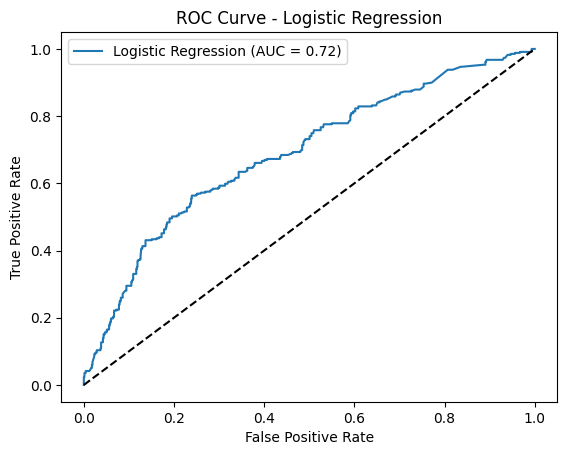

In [134]:
# ROC for Train
log_roc_auc = roc_auc_score(y_train_b, train_probs)
log_gini = 2 * log_roc_auc - 1
print(f"Logistic Regression - ROC AUC: {log_roc_auc}, GINI: {log_gini}")

fpr, tpr, _ = roc_curve(y_test_b, test_probs)
plt.plot(fpr, tpr, label='Logistic Regression (AUC = %0.2f)' % log_roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

Logistic Regression - ROC AUC: 0.6879955933803857, GINI: 0.3759911867607715


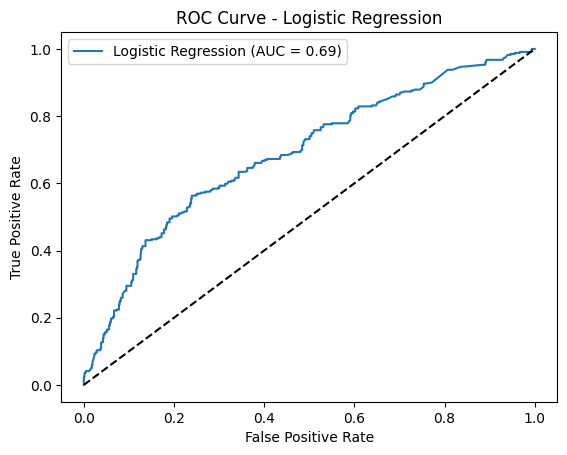

In [135]:
# ROC for Test
log_roc_auc = roc_auc_score(y_test_b, test_probs)
log_gini = 2 * log_roc_auc - 1
print(f"Logistic Regression - ROC AUC: {log_roc_auc}, GINI: {log_gini}")

fpr, tpr, _ = roc_curve(y_test_b, test_probs)
plt.plot(fpr, tpr, label='Logistic Regression (AUC = %0.2f)' % log_roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

Thanks.